# House Price Prediction - Model Training & Comparison

In this notebook, we train and compare multiple regression models on the USA Housing dataset. Based on the EDA findings, we know the relationships are predominantly linear, so we start with Linear Regression as a baseline and then explore Polynomial Regression with Ridge regularization and K-Nearest Neighbors. The best model will be selected based on Test R-squared score and saved as a pipeline for deployment.

## 1. Load Data and Split

We load the dataset and select features based on our EDA findings. All five numerical features are included since they all show positive correlation with Price. The Address column is excluded as it is a text identifier with no predictive value. We use an 80/20 train-test split for evaluation.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('../data/usa_housing.csv')
print(f'Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')

# Select features based on EDA findings
feature_columns = ['Avg. Area Income', 'Avg. Area House Age', 
                   'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 
                   'Area Population']

X = df[feature_columns]
y = df['Price']

print(f'Features: {feature_columns}')
print(f'Target: Price')
print(f'Feature matrix shape: {X.shape}')

Dataset loaded: 5000 rows, 7 columns
Features: ['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population']
Target: Price
Feature matrix shape: (5000, 5)


In [3]:
# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')

Training set: 4000 samples
Test set:     1000 samples


## 2. Train Multiple Models

We train three different regression models:
1. **Linear Regression**: A simple baseline model assuming linear relationships
2. **Polynomial Regression (degree 2) + Ridge**: Captures non-linear relationships with L2 regularization
3. **K-Nearest Neighbors (k=5)**: A non-parametric model that predicts based on similarity

All models use a scikit-learn Pipeline with StandardScaler for consistent feature scaling.

### Model 1: Linear Regression

In [4]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

# Predictions
lr_train_pred = lr_pipeline.predict(X_train)
lr_test_pred = lr_pipeline.predict(X_test)

# Metrics
lr_train_r2 = r2_score(y_train, lr_train_pred)
lr_test_r2 = r2_score(y_test, lr_test_pred)
lr_test_mse = mean_squared_error(y_test, lr_test_pred)

print('Linear Regression Results:')
print(f'  Train R2: {lr_train_r2:.4f}')
print(f'  Test R2:  {lr_test_r2:.4f}')
print(f'  Test MSE: ${lr_test_mse:,.2f}')

Linear Regression Results:
  Train R2: 0.9180
  Test R2:  0.9180
  Test MSE: $10,089,009,300.89


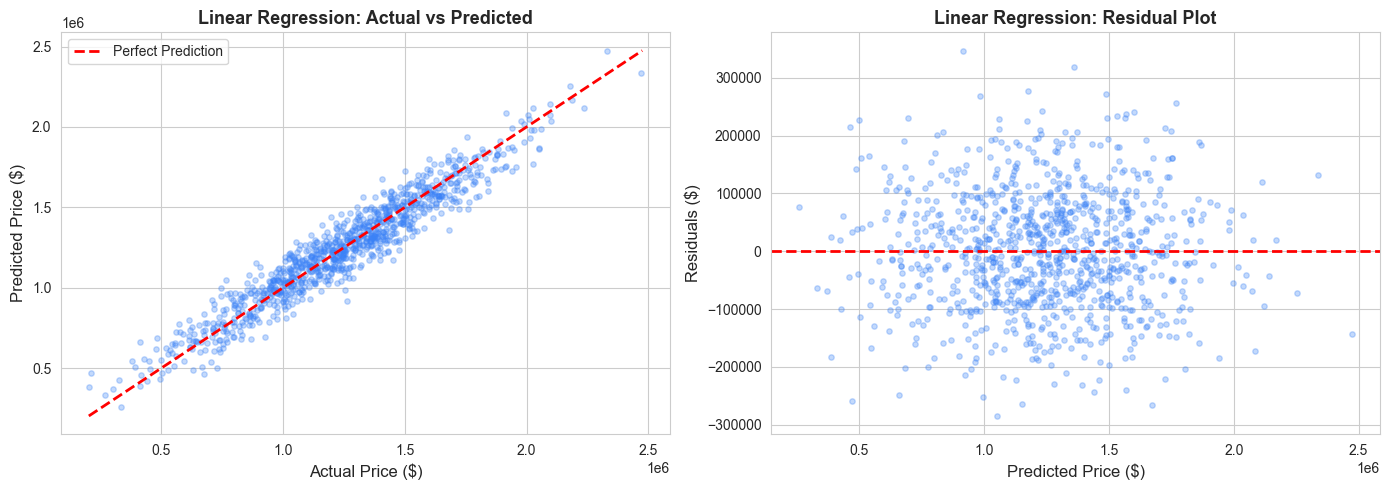

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test, lr_test_pred, alpha=0.3, s=15, color='#3B82F6')
min_val = min(y_test.min(), lr_test_pred.min())
max_val = max(y_test.max(), lr_test_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price ($)', fontsize=12)
axes[0].set_ylabel('Predicted Price ($)', fontsize=12)
axes[0].set_title('Linear Regression: Actual vs Predicted', fontsize=13, fontweight='bold')
axes[0].legend()

# Residuals
residuals = y_test - lr_test_pred
axes[1].scatter(lr_test_pred, residuals, alpha=0.3, s=15, color='#3B82F6')
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Price ($)', fontsize=12)
axes[1].set_ylabel('Residuals ($)', fontsize=12)
axes[1].set_title('Linear Regression: Residual Plot', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### Model 2: Polynomial Regression (degree 2) + Ridge

In [6]:
# Model 2: Polynomial Regression (degree 2) + Ridge
poly_ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', Ridge(alpha=1.0))
])

poly_ridge_pipeline.fit(X_train, y_train)

# Predictions
pr_train_pred = poly_ridge_pipeline.predict(X_train)
pr_test_pred = poly_ridge_pipeline.predict(X_test)

# Metrics
pr_train_r2 = r2_score(y_train, pr_train_pred)
pr_test_r2 = r2_score(y_test, pr_test_pred)
pr_test_mse = mean_squared_error(y_test, pr_test_pred)

print('Polynomial (degree 2) + Ridge Results:')
print(f'  Train R2: {pr_train_r2:.4f}')
print(f'  Test R2:  {pr_test_r2:.4f}')
print(f'  Test MSE: ${pr_test_mse:,.2f}')

Polynomial (degree 2) + Ridge Results:
  Train R2: 0.9181
  Test R2:  0.9179
  Test MSE: $10,099,222,956.71


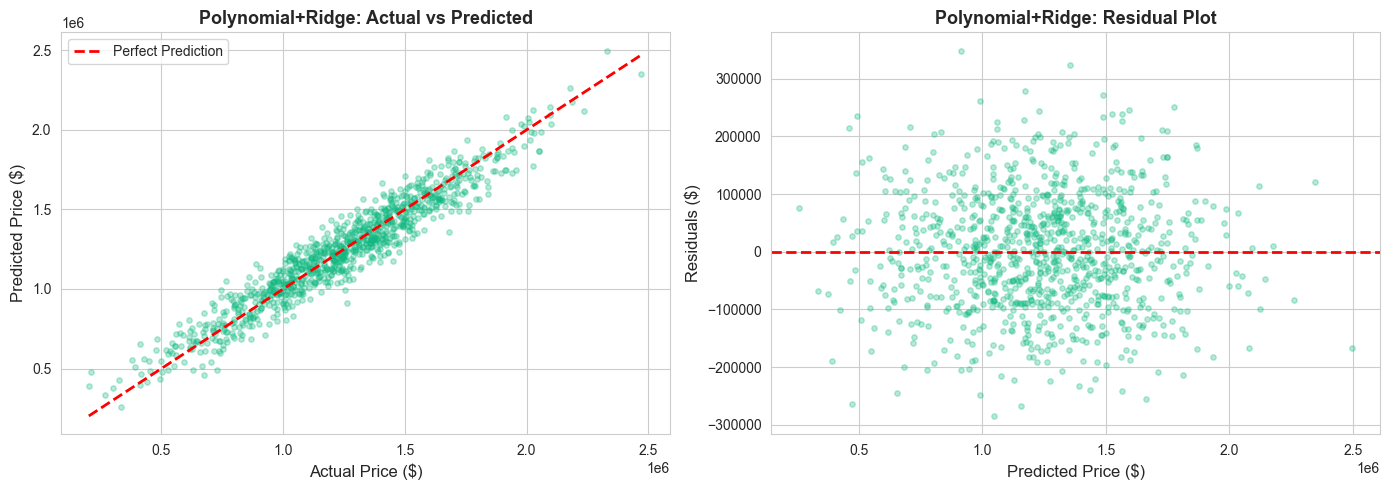

In [7]:
# Visualize Polynomial + Ridge predictions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, pr_test_pred, alpha=0.3, s=15, color='#10B981')
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price ($)', fontsize=12)
axes[0].set_ylabel('Predicted Price ($)', fontsize=12)
axes[0].set_title('Polynomial+Ridge: Actual vs Predicted', fontsize=13, fontweight='bold')
axes[0].legend()

pr_residuals = y_test - pr_test_pred
axes[1].scatter(pr_test_pred, pr_residuals, alpha=0.3, s=15, color='#10B981')
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Price ($)', fontsize=12)
axes[1].set_ylabel('Residuals ($)', fontsize=12)
axes[1].set_title('Polynomial+Ridge: Residual Plot', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### Model 3: K-Nearest Neighbors (k=5)

In [8]:
# Model 3: KNN Regressor (k=5)
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsRegressor(n_neighbors=5))
])

knn_pipeline.fit(X_train, y_train)

# Predictions
knn_train_pred = knn_pipeline.predict(X_train)
knn_test_pred = knn_pipeline.predict(X_test)

# Metrics
knn_train_r2 = r2_score(y_train, knn_train_pred)
knn_test_r2 = r2_score(y_test, knn_test_pred)
knn_test_mse = mean_squared_error(y_test, knn_test_pred)

print('KNN (k=5) Results:')
print(f'  Train R2: {knn_train_r2:.4f}')
print(f'  Test R2:  {knn_test_r2:.4f}')
print(f'  Test MSE: ${knn_test_mse:,.2f}')

KNN (k=5) Results:
  Train R2: 0.9109
  Test R2:  0.8693
  Test MSE: $16,078,241,760.75


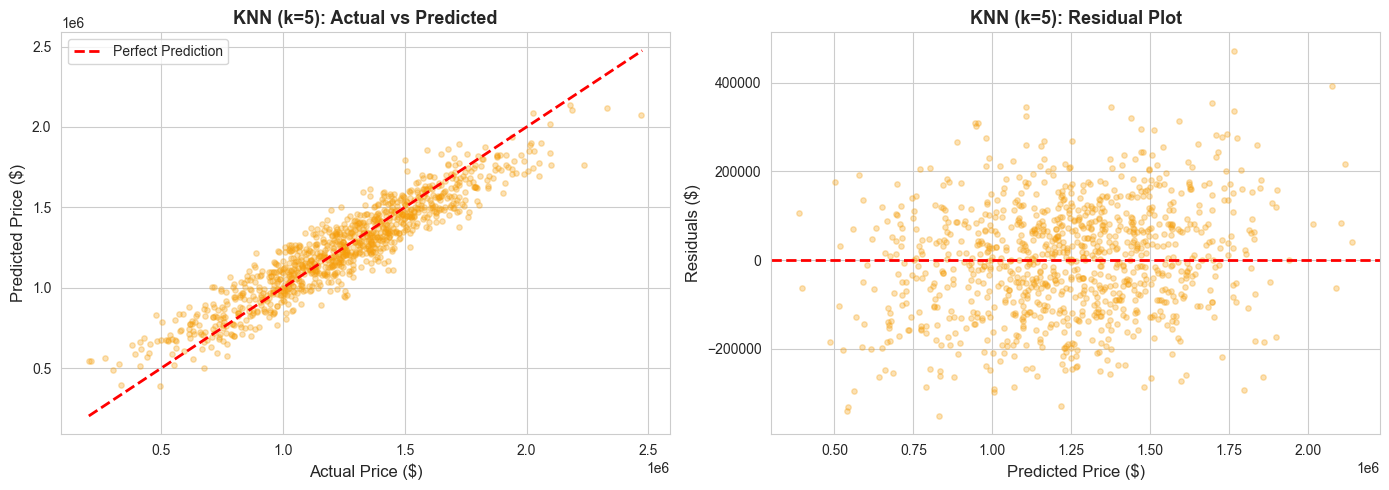

In [9]:
# Visualize KNN predictions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, knn_test_pred, alpha=0.3, s=15, color='#F59E0B')
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price ($)', fontsize=12)
axes[0].set_ylabel('Predicted Price ($)', fontsize=12)
axes[0].set_title('KNN (k=5): Actual vs Predicted', fontsize=13, fontweight='bold')
axes[0].legend()

knn_residuals = y_test - knn_test_pred
axes[1].scatter(knn_test_pred, knn_residuals, alpha=0.3, s=15, color='#F59E0B')
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Price ($)', fontsize=12)
axes[1].set_ylabel('Residuals ($)', fontsize=12)
axes[1].set_title('KNN (k=5): Residual Plot', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Model Comparison Table

We compare all trained models using Train R-squared, Test R-squared, and Test MSE.

In [10]:
# Model comparison table
comparison_data = {
    'Model': ['Linear Regression', 'Polynomial (degree 2) + Ridge', 'KNN (k=5)'],
    'Train R2': [lr_train_r2, pr_train_r2, knn_train_r2],
    'Test R2': [lr_test_r2, pr_test_r2, knn_test_r2],
    'Test MSE': [lr_test_mse, pr_test_mse, knn_test_mse]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Test R2', ascending=False).reset_index(drop=True)

display_df = comparison_df.copy()
display_df['Train R2'] = display_df['Train R2'].round(4)
display_df['Test R2'] = display_df['Test R2'].round(4)
display_df['Test MSE'] = display_df['Test MSE'].apply(lambda x: f'${x:,.2f}')

print('Model Comparison Table:')
print('=' * 80)
print(display_df.to_string(index=False))
print('=' * 80)

Model Comparison Table:
                        Model  Train R2  Test R2           Test MSE
            Linear Regression    0.9180   0.9180 $10,089,009,300.89
Polynomial (degree 2) + Ridge    0.9181   0.9179 $10,099,222,956.71
                    KNN (k=5)    0.9109   0.8693 $16,078,241,760.75


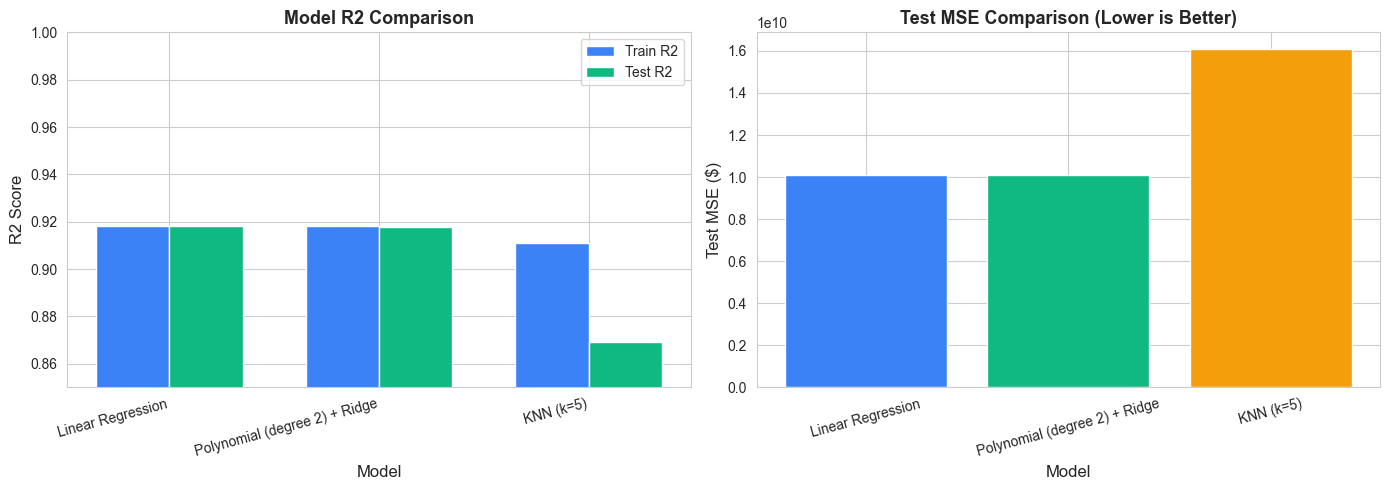

In [11]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = comparison_df['Model'].tolist()
train_r2 = comparison_df['Train R2'].tolist()
test_r2 = comparison_df['Test R2'].tolist()

x = np.arange(len(models))
width = 0.35

bars1 = axes[0].bar(x - width/2, train_r2, width, label='Train R2', color='#3B82F6', edgecolor='white')
bars2 = axes[0].bar(x + width/2, test_r2, width, label='Test R2', color='#10B981', edgecolor='white')
axes[0].set_xlabel('Model', fontsize=12)
axes[0].set_ylabel('R2 Score', fontsize=12)
axes[0].set_title('Model R2 Comparison', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=15, ha='right', fontsize=10)
axes[0].legend()
axes[0].set_ylim([0.85, 1.0])

test_mse = comparison_df['Test MSE'].tolist()
axes[1].bar(models, test_mse, color=['#3B82F6', '#10B981', '#F59E0B'], edgecolor='white')
axes[1].set_xlabel('Model', fontsize=12)
axes[1].set_ylabel('Test MSE ($)', fontsize=12)
axes[1].set_title('Test MSE Comparison (Lower is Better)', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## 4. Select Best Model

The best model is selected based on the highest Test R-squared score. We also check for overfitting.

In [12]:
# Select best model
best_idx = comparison_df['Test R2'].idxmax()
best_model_name = comparison_df.loc[best_idx, 'Model']
best_test_r2 = comparison_df.loc[best_idx, 'Test R2']
best_test_mse = comparison_df.loc[best_idx, 'Test MSE']

pipelines = {
    'Linear Regression': lr_pipeline,
    'Polynomial (degree 2) + Ridge': poly_ridge_pipeline,
    'KNN (k=5)': knn_pipeline
}

best_pipeline = pipelines[best_model_name]

print(f'Best Model: {best_model_name}')
print(f'Test R2:  {best_test_r2:.4f}')
print(f'Test MSE: ${best_test_mse:,.2f}')
print()

train_r2_best = comparison_df.loc[best_idx, 'Train R2']
gap = train_r2_best - best_test_r2
print(f'Train R2: {train_r2_best:.4f}')
print(f'Train-Test R2 Gap: {gap:.4f}')
if gap < 0.02:
    print('Overfitting check: PASS (gap < 0.02, minimal overfitting)')
elif gap < 0.05:
    print('Overfitting check: ACCEPTABLE (gap < 0.05, slight overfitting)')
else:
    print('Overfitting check: WARNING (gap >= 0.05, significant overfitting)')

Best Model: Linear Regression
Test R2:  0.9180
Test MSE: $10,089,009,300.89

Train R2: 0.9180
Train-Test R2 Gap: -0.0000
Overfitting check: PASS (gap < 0.02, minimal overfitting)


In [13]:
print('Model Selection Rationale:')
print('=' * 60)
print()
if 'Linear' in best_model_name:
    print(f'{best_model_name} achieved the best Test R2 of {best_test_r2:.4f}.')
    print('This confirms the EDA finding that relationships between features')
    print('and Price are predominantly linear. The simplicity of linear')
    print('regression also makes it highly interpretable and less prone to')
    print('overfitting compared to more complex models.')
elif 'Polynomial' in best_model_name:
    print(f'{best_model_name} achieved the best Test R2 of {best_test_r2:.4f}.')
    print('This model captures non-linear relationships through polynomial')
    print('feature engineering while the Ridge regularization prevents')
    print('overfitting on the expanded feature space.')
else:
    print(f'{best_model_name} achieved the best Test R2 of {best_test_r2:.4f}.')
    print('The KNN model captures local patterns in the feature space that')
    print('global models like linear regression may miss.')

Model Selection Rationale:

Linear Regression achieved the best Test R2 of 0.9180.
This confirms the EDA finding that relationships between features
and Price are predominantly linear. The simplicity of linear
regression also makes it highly interpretable and less prone to
overfitting compared to more complex models.


## 5. Save Pipeline

The best model pipeline is saved to disk using joblib. This allows the Gradio app to load it for predictions.

In [14]:
model_path = '../models/best_model.pkl'
joblib.dump(best_pipeline, model_path)
print(f'Best model pipeline saved to: {model_path}')
print(f'Model: {best_model_name}')

loaded_pipeline = joblib.load(model_path)
test_prediction = loaded_pipeline.predict(X_test[:1])
print(f'\nVerification: Loaded model prediction for first test sample: ${test_prediction[0]:,.2f}')
print(f'Actual price: ${y_test.iloc[0]:,.2f}')

Best model pipeline saved to: ../models/best_model.pkl
Model: Linear Regression

Verification: Loaded model prediction for first test sample: $1,308,587.93
Actual price: $1,339,096.08
